<a href="https://colab.research.google.com/github/AnushkaaBhargava/plant-disease-detection/blob/main/training/training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [80]:
import tensorflow as tf
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt

In [81]:
IMAGE_SIZE=256
BATCH_SIZE=32
EPOCHS=30
CHANNELS=3

In [82]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [83]:
dataset=tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/PlantVillage",
    shuffle=True,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 2152 files belonging to 3 classes.


In [84]:
class_names=dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

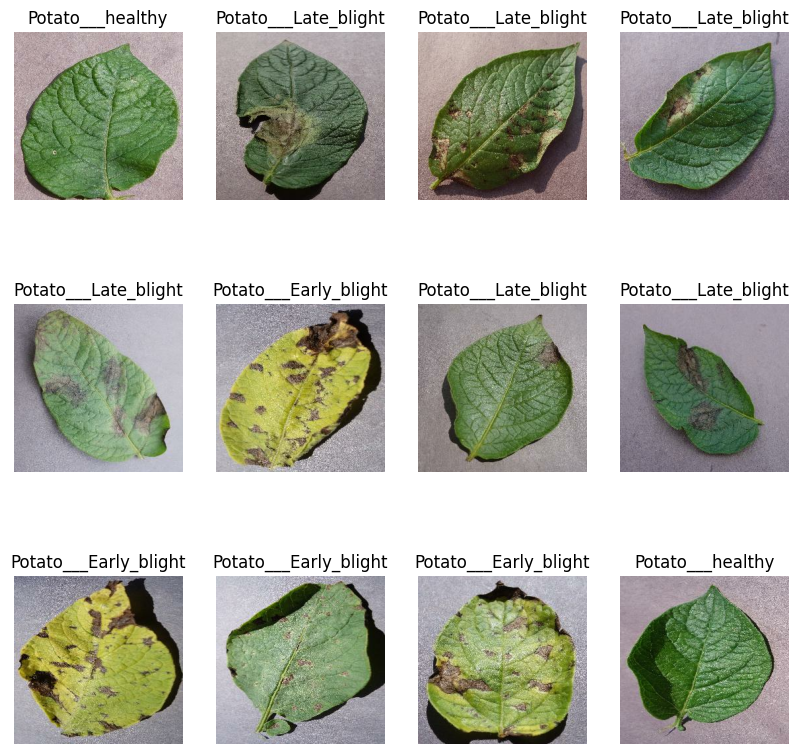

In [85]:
plt.figure(figsize=(10,10))
for image_batch,label_batch in dataset.take(1):
    for i in range(12):
        ax=plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")



In [86]:
len(dataset)

68

In [87]:
train_size=0.8
len(dataset)*train_size

54.400000000000006

In [88]:
train_ds=dataset.take(54)
len(train_ds)

54

In [89]:
test_ds=dataset.skip(54)
len(test_ds)

14

In [90]:
val_size=0.1
len(dataset)*val_size


6.800000000000001

In [91]:
val_ds=test_ds.take(6)
len(val_ds)

6

In [92]:
test_ds=test_ds.skip(6)
len(test_ds)

8

In [93]:
def get_dataset_paritions(ds,train_split=0.8,val_split=0.1,test_split=0.1,shuffle=True,shuffle_size=10000):
    ds_size=len(ds)

    if shuffle:
        ds=ds.shuffle(shuffle_size,seed=12)
    train_size=int(train_split*ds_size)
    val_size=int(val_split*ds_size)
    train_ds=ds.take(train_size)
    val_ds=ds.skip(train_size).take(val_size)
    test_ds=ds.skip(train_size).skip(val_size)
    return train_ds,val_ds,test_ds



In [94]:
train_ds,val_ds,test_ds=get_dataset_paritions(dataset)

In [95]:
len(train_ds)

54

In [96]:
len(val_ds)

6

In [97]:
len(test_ds)

8

In [98]:
train_ds=train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds=val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds=test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [99]:
resize_and_rescale=tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE,IMAGE_SIZE),
    layers.Rescaling(1.0/255)
])

In [100]:
data_augmentation=tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])

In [101]:
from tensorflow.keras import layers, models

input_shape = (IMAGE_SIZE, IMAGE_SIZE, 3)
n_classes = 3

model = models.Sequential([
    layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),  # 👈 add this line
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(n_classes, activation="softmax")
])
model.summary()


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_6 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [102]:
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

In [104]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Change the file extension here
checkpoint_filepath = '/content/drive/MyDrive/best_model_checkpoint.weights.h5' # <-- Changed from .keras

# Create the ModelCheckpoint callback (rest of the code is the same)
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1
)

# Now you can use this callback in model.fit()
# history = model.fit(..., callbacks=[model_checkpoint_callback])

history=model.fit(
    train_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    validation_data=val_ds,
    callbacks=[model_checkpoint_callback]
)

Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.4601 - loss: 0.9341
Epoch 1: val_loss improved from inf to 0.84587, saving model to /content/drive/MyDrive/best_model_checkpoint.weights.h5
54/54 ━━━━━━━━━━━━━━━━━━━━ 18s 181ms/step - accuracy: 0.4605 - loss: 0.9335 - val_accuracy: 0.5104 - val_loss: 0.8459
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5848 - loss: 0.7779
Epoch 2: val_loss improved from 0.84587 to 0.48318, saving model to /content/drive/MyDrive/best_model_checkpoint.weights.h5
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.5863 - loss: 0.7764 - val_accuracy: 0.8177 - val_loss: 0.4832
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.7715 - loss: 0.5282
Epoch 3: val_loss improved from 0.48318 to 0.36288, saving model to /content/drive/MyDrive/best_model_checkpoint.weights.h5
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.7718 - loss: 0.5275 - val_accuracy: 0.8281 - val_loss: 0.3629
Epoch 4/30
54/54 ━━━━━━━━━━

In [105]:
scores=model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9639 - loss: 0.1067


In [106]:
scores

[0.11909638345241547, 0.96484375]

In [107]:
history

In [108]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [109]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [110]:
acc=history.history["accuracy"]
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']

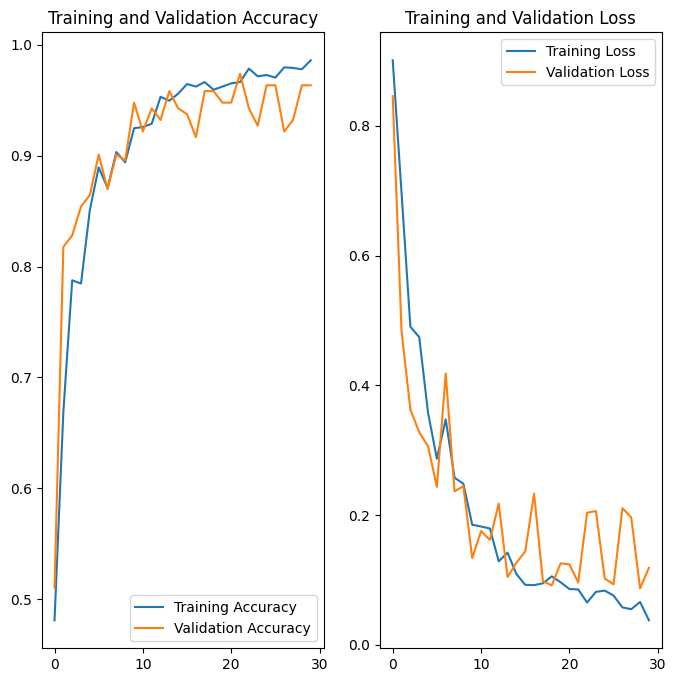

In [111]:
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS),acc,label='Training Accuracy')
plt.plot(range(EPOCHS),val_acc,label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title("Training and Validation Accuracy")

plt.subplot(1,2,2)
plt.plot(range(EPOCHS),loss,label='Training Loss')
plt.plot(range(EPOCHS),val_loss,label='Validation Loss')
plt.legend(loc='upper right')
plt.title("Training and Validation Loss")
plt.show()




first image to predict
first image's actual label: Potato___Late_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
predicted label: Potato___Late_blight


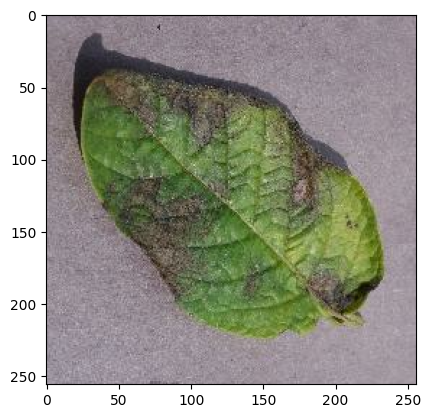

In [112]:
import numpy as np
for images_batch,labels_batch in test_ds.take(1):
  first_image=images_batch[0].numpy().astype('uint8')
  first_label=labels_batch[0].numpy()
  print("first image to predict")
  plt.imshow(first_image)
  print("first image's actual label:",class_names[first_label])

  batch_prediction=model.predict(images_batch)
  print("predicted label:",class_names[np.argmax(batch_prediction[0])])

In [113]:
import tensorflow as tf
import numpy as np

def predict(model, img):
  """
  Makes a prediction on a single image using the trained model.

  Args:
    model: The trained tf.keras model.
    img: The input image (e.g., loaded using tf.keras.utils.load_img or as a NumPy array).
    class_names: A list of strings containing the names of the classes.

  Returns:
    A tuple containing the predicted class name (string) and the confidence score (float).
  """
  # Convert the image to a NumPy array
  img_array = tf.keras.preprocessing.image.img_to_array(img)

  # Add a batch dimension (model expects batches)
  img_array = tf.expand_dims(img_array, 0) # Create a batch of size 1

  # Get model predictions (an array of probabilities for each class)
  predictions = model.predict(img_array)

  # Find the class index with the highest probability
  predicted_index = np.argmax(predictions[0])

  # Get the corresponding class name
  predicted_class = class_names[predicted_index]

  # Get the confidence score (highest probability)
  confidence = round(100 * (np.max(predictions[0])), 2)

  return predicted_class, confidence

# --- Example Usage (replace with your actual variables) ---
# Assuming you have:
# 1. Loaded your trained Keras model into the variable 'model'
# 2. A list of your class labels in 'class_names' (e.g., ['ClassA', 'ClassB', 'ClassC'])
# 3. Loaded an image you want to predict into 'my_image'
#    (e.g., my_image = tf.keras.utils.load_img('path/to/your/image.jpg', target_size=(IMAGE_SIZE, IMAGE_SIZE)))

# predicted_label, confidence_score = predict(model, my_image)
# print(f"Predicted Class: {predicted_label}")
# print(f"Confidence: {confidence_score}%")
# --- End Example ---

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


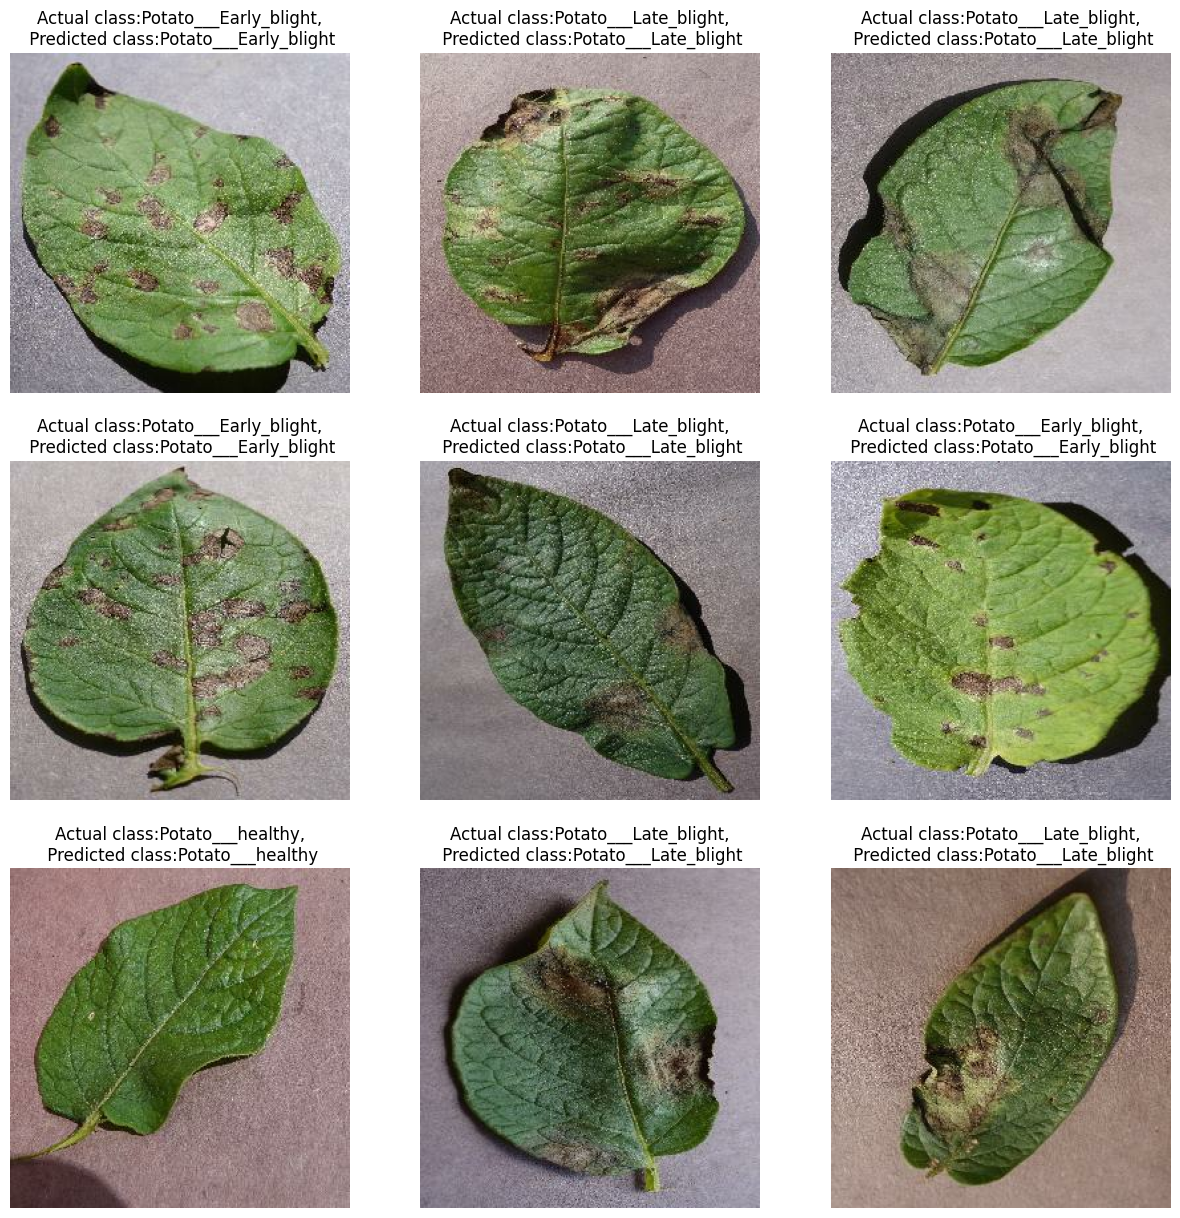

In [116]:
plt.figure(figsize=(15,15))
for images,labels in test_ds.take(1):
  for i in range(9):
    ax=plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype('uint8'))
    predicted_class, confidence=predict(model,images[i].numpy())
    actual_class=class_names[labels[i]]
    plt.title(f"Actual class:{actual_class},\n Predicted class:{predicted_class}")
    plt.axis("off")